# SESSION 2 - Autoencoders & Variational Autoencoders (VAE)


### 1.
**Build a simple autoencoder in Python using Keras to compress and reconstruct 28x28 grayscale images from the Fashion MNIST dataset. Train for 5 epochs and display one original and its reconstructed image side by side.**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

In [2]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [3]:
input_img = layers.Input(shape=(28, 28))
x = layers.Flatten()(input_img)
encoded = layers.Dense(64, activation='relu')(x)
decoded = layers.Dense(784, activation='sigmoid')(encoded)
output_img = layers.Reshape((28, 28))(decoded)

In [4]:
autoencoder_mse = models.Model(input_img, output_img)
autoencoder_mse.compile(optimizer='adam', loss='mse')

In [5]:
autoencoder_mse.fit(x_train, x_train, epochs=5, batch_size=256, shuffle=True, validation_data=(x_test, x_test), verbose=1)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0528 - val_loss: 0.0287
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0244 - val_loss: 0.0213
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0185 - val_loss: 0.0164
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0149 - val_loss: 0.0138
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0131 - val_loss: 0.0127


In [6]:
decoded_imgs_mse = autoencoder_mse.predict(x_test[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


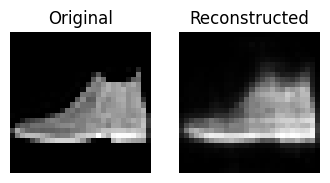

In [9]:
plt.figure(figsize=(4, 2))
# Original
ax = plt.subplot(1, 2, 1)
plt.imshow(x_test[0], cmap='gray')
ax.set_title("Original")
ax.axis('off')
# Reconstructed
ax = plt.subplot(1, 2, 2)
plt.imshow(decoded_imgs_mse[0], cmap='gray')
ax.set_title("Reconstructed")
ax.axis('off')
plt.show()

### 2.
**Modify your autoencoder's loss function to use Binary Crossentropy (BCE) instead of Mean Squared Error (MSE), then compare the reconstruction quality visually for 3 test images.**


In [10]:
autoencoder_bce = models.Model(input_img, output_img)
autoencoder_bce.compile(optimizer='adam', loss='binary_crossentropy')

In [11]:
autoencoder_bce.fit(x_train, x_train, epochs=5, batch_size=256, shuffle=True, validation_data=(x_test, x_test), verbose=1)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2838 - val_loss: 0.2835
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.2803 - val_loss: 0.2815
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2785 - val_loss: 0.2800
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2773 - val_loss: 0.2789
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2762 - val_loss: 0.2779


In [12]:
decoded_imgs_bce = autoencoder_bce.predict(x_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


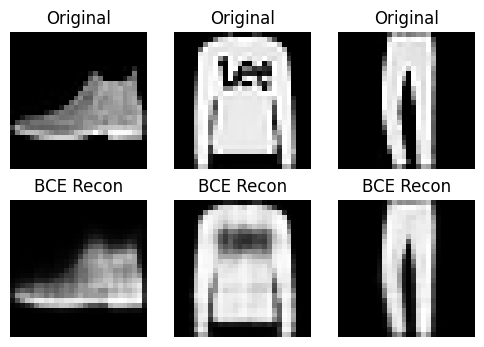

In [17]:
plt.figure(figsize=(6, 4))
for i in range(3):
    ax = plt.subplot(2, 3, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    ax.set_title("Original")
    ax.axis('off')
    ax = plt.subplot(2, 3, i + 4)
    plt.imshow(decoded_imgs_bce[i], cmap='gray')
    ax.set_title("BCE Recon")
    ax.axis('off')
plt.show()

### 3.
**Use your trained autoencoder to denoise images: add random noise to 10 Fashion MNIST test images, pass them through the autoencoder, and display the noisy and denoised outputs together.**


In [18]:
noise_factor = 0.2
x_test_noisy = x_test[:10] + noise_factor * tf.random.normal(shape=(10, 28, 28)).numpy()
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.).numpy()

In [19]:
denoised_imgs = autoencoder_bce.predict(x_test_noisy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


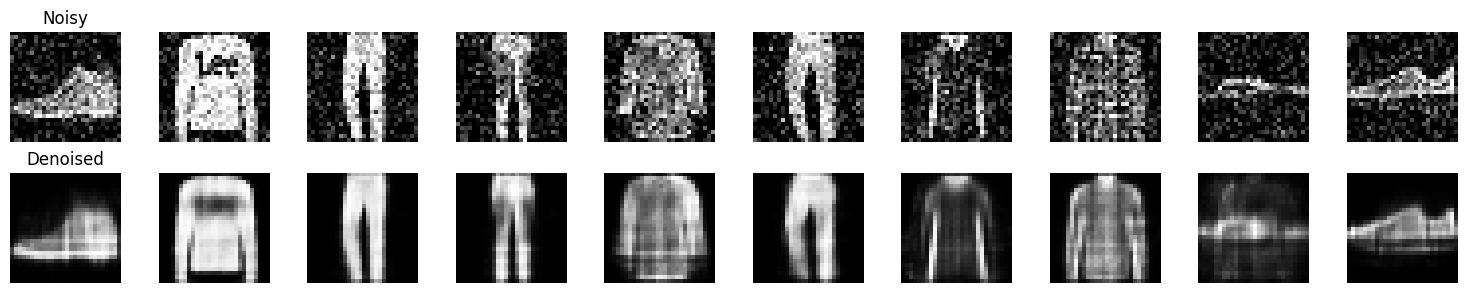

In [21]:
plt.figure(figsize=(15, 3))
for i in range(10):
    # Noisy
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test_noisy[i], cmap='gray')
    ax.axis('off')
    if i == 0: ax.set_title("Noisy")
    # Denoised
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(denoised_imgs[i], cmap='gray')
    ax.axis('off')
    if i == 0: ax.set_title("Denoised")
plt.tight_layout()
plt.show()

### 4.
**Build a Variational Autoencoder (VAE) using Keras for the Fashion MNIST dataset. After training, sample 5 random points from the latent space and generate new images from these points.**


In [22]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 2

In [23]:
encoder_inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = models.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

In [24]:
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28, 28, 1))(x)
decoder = models.Model(latent_inputs, decoder_outputs, name="decoder")

In [25]:
class VAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
            
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        return {"loss": self.total_loss_tracker.result()}

In [26]:
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

In [27]:
x_train_vae = np.expand_dims(x_train, -1)
vae.fit(x_train_vae, epochs=5, batch_size=128, verbose=1)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 321.4843
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 282.8216
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 278.4091
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 275.5688
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 273.5600


In [28]:
random_latent_points = np.random.normal(size=(5, latent_dim))
generated_images = decoder.predict(random_latent_points)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


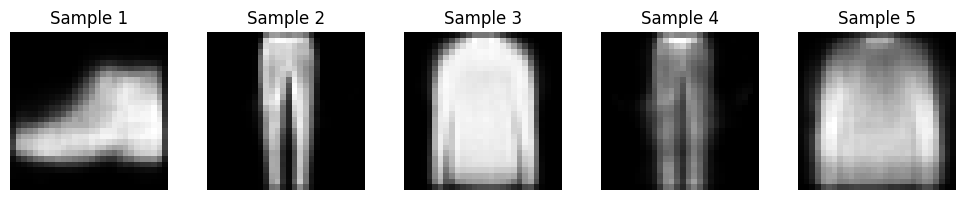

In [29]:
plt.figure(figsize=(10, 2))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(generated_images[i, :, :, 0], cmap='gray')
    ax.set_title(f"Sample {i+1}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### 5.
**Use ChatGPT to explain in your own words what KL-divergence loss does in a VAE and why it is needed. Paste your prompt and ChatGPT's response as your answer.**

---
**My Prompt:**  
> "Explain in simple words what KL-divergence loss does in a Variational Autoencoder (VAE) and why it is needed."

**ChatGPT's Response:**  
> "In a Variational Autoencoder, the KL-divergence loss acts as a mathematical 'rubber band' that keeps the encoded data organized. Instead of letting the model scatter the encoded points randomly, KL-divergence forces the latent space to closely match a standard normal distribution (a neat, continuous bell curve). 
> 
> Why is this needed? If we didn't have KL-divergence, the model would just memorize the training images and create empty gaps between points in the latent space. By keeping everything packed smoothly together, it ensures that when you randomly pick any point in that space, the decoder can generate a realistic, completely new image!"
